<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologias Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Linea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibague-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingenieria</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingenieria de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab — 01 Data Ingestion</div>

# 01 — Data Ingestion

Este notebook cubre el primer paso del pipeline: **cargar el dataset crudo**.

`src/data/ingestion.py` se encarga de:
1. Leer el `.zip` con las imagenes de aves
2. Extraer cada carpeta de clase en `data/raw/`
3. Reportar cuantas imagenes encontro por especie

La configuracion (rutas, tamanio de imagen, splits) se lee desde `configs/dataset.yaml`.

```
dataset.zip
├── ESPECIE_A/  →  data/raw/ESPECIE_A/
├── ESPECIE_B/  →  data/raw/ESPECIE_B/
└── ...
```


## 1. Verificar configuracion

In [1]:
import sys
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Asegurar que src/ esta en el path para importar ingestion
PROJECT_ROOT = Path.cwd().parent   
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print("Configuracion cargada desde:", CONFIG_PATH)
print()
for k, v in config.items():
    print(f"  {k:<25} {v}")


Configuracion cargada desde: D:\desarrollo\bird-lab\configs\dataset.yaml

  raw_data_path             data/raw
  processed_data_path       data/processed
  split_ratio               [0.75, 0.15, 0.1]
  image_size                224
  min_confidence            0.5
  min_bbox_area_ratio       0.05
  margin_ratio              0.2
  hard_min_confidence       0.3
  hard_min_bbox_area_ratio  0.02
  soft_min_confidence       0.6
  soft_min_bbox_area_ratio  0.08
  min_aspect_ratio          0.5
  max_aspect_ratio          2.0


## 2. Ejecutar la ingestion

Ajusta `ZIP_PATH` a la ruta de tu archivo `.zip`.  
El resto lo resuelve `ingest_zip()` automaticamente.


In [2]:
from src.utils.ingestion import ingest_zip

# ── Ruta al archivo zip ─────────────────────────────────────────
ZIP_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.zip"

result = ingest_zip(
    zip_path=str(ZIP_PATH),
    config_path=str(CONFIG_PATH),
    verbose=True,        # imprime el reporte en consola
)


────────────────────────────────────────────────────
  INGESTION REPORT — W&F BirdLab
────────────────────────────────────────────────────
  Origen  : D:\desarrollo\bird-lab\data\raw\dataset.zip
  Destino : data\raw
  Clases encontradas: 16

  Clase                               Imagenes
  ----------------------------------- --------
  ardea-alba                              1620
  atlapetes-latinuchus                    1077
  butorides-striata                       1078
  chlorochrysa-nitidissima                1374
  colibri-coruscans                       1431
  gallinula-galeata                       1499
  metallura-tyrianthina                   1259
  momotus-aequatorialis                   1677
  phimosus-infuscatus                     1613
  piaya-cayana                            1259
  pitangus-sulphuratus                    1438
  ramphastos-ambiguus                     2091
  sicalis-flaveola                        1558
  thraupis-episcopus                      1256
  turd

## 3. Resultados basicos

In [3]:
classes      = result["classes"]
counts       = result["counts"]
total_images = result["total_images"]
raw_dir      = result["raw_dir"]
skipped      = result["skipped_files"]

print(f"Clases encontradas : {len(classes)}")
print(f"Total de imagenes  : {total_images}")
print(f"Archivos ignorados : {len(skipped)}")
print(f"Directorio raw     : {raw_dir.resolve()}")


Clases encontradas : 16
Total de imagenes  : 23224
Archivos ignorados : 0
Directorio raw     : D:\desarrollo\bird-lab\notebooks\data\raw


## 4. Distribucion de imagenes por clase

Una distribucion muy desigual (clases con pocas imagenes vs. clases con muchas)
puede causar que el modelo aprenda mejor unas especies que otras.
Esto es lo primero que debemos revisar antes de entrenar.


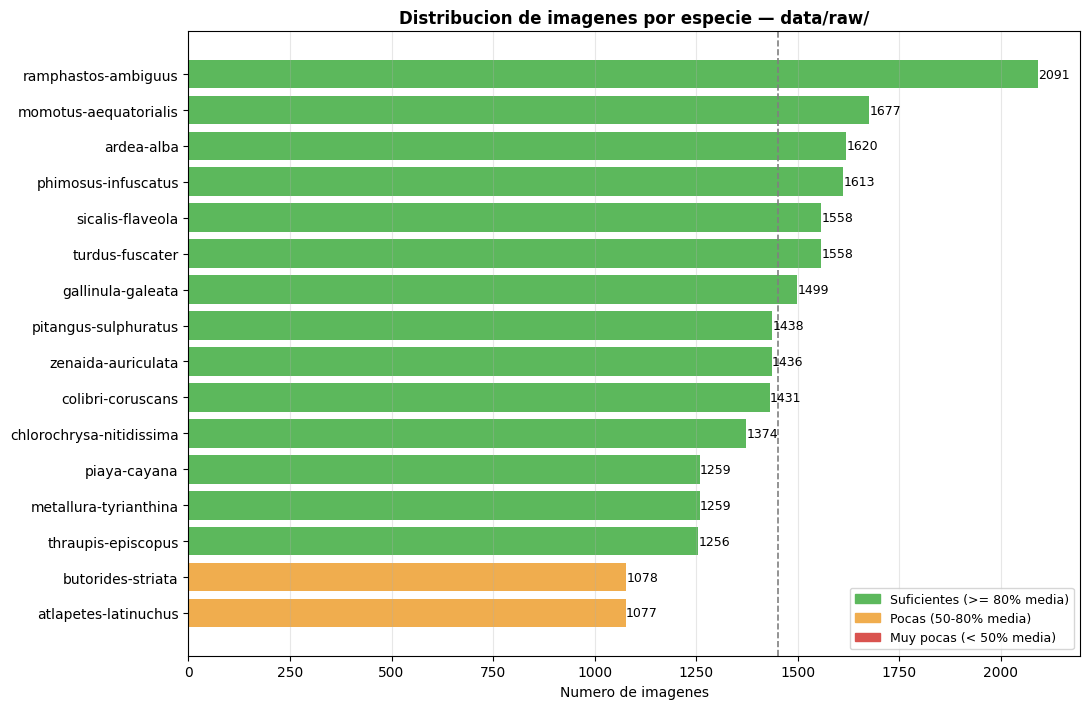

Grafica guardada en logs/01_distribucion_raw.png


In [4]:
sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
sorted_cls   = [k for k, _ in sorted_items]
sorted_cnt   = [v for _, v in sorted_items]

mean_count = np.mean(sorted_cnt)
colors = [
    "#d9534f" if v < mean_count * 0.5 else
    "#f0ad4e" if v < mean_count * 0.8 else
    "#5cb85c"
    for v in sorted_cnt
]

fig, ax = plt.subplots(figsize=(11, max(5, len(classes) * 0.45)))
bars = ax.barh(sorted_cls[::-1], sorted_cnt[::-1], color=colors[::-1])
ax.axvline(x=mean_count, color="gray", linestyle="--", linewidth=1.2,
           label=f"Media: {mean_count:.0f} imgs")

for bar, val in zip(bars, sorted_cnt[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)

patches = [
    mpatches.Patch(color="#5cb85c", label="Suficientes (>= 80% media)"),
    mpatches.Patch(color="#f0ad4e", label="Pocas (50-80% media)"),
    mpatches.Patch(color="#d9534f", label="Muy pocas (< 50% media)"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9)
ax.set_xlabel("Numero de imagenes")
ax.set_title("Distribucion de imagenes por especie — data/raw/", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "logs" / "01_distribucion_raw.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada en logs/01_distribucion_raw.png")


## 5. Tabla resumen y alertas

In [5]:
mean_count = np.mean(list(counts.values()))

print(f"{'Clase':<35} {'Imagenes':>9}  {'Estado'}")
print("-" * 62)
for cls in sorted_cls:
    n = counts[cls]
    if   n < mean_count * 0.5:  estado = "[!] Muy pocas imagenes"
    elif n < mean_count * 0.8:  estado = "[~] Pocas imagenes"
    else:                        estado = "[OK]"
    print(f"{cls:<35} {n:>9}  {estado}")

print("-" * 62)
print(f"{'TOTAL':<35} {total_images:>9}")
print(f"{'Media por clase':<35} {mean_count:>9.1f}")
print()

clases_bajas = [c for c in classes if counts[c] < mean_count * 0.5]
if clases_bajas:
    print("Clases con muy pocas imagenes (< 50% de la media):")
    for c in clases_bajas:
        print(f"  - {c}: {counts[c]} imagenes")
    print()
    print("Recomendacion: recolectar mas imagenes de estas clases antes")
    print("de pasar a la etapa de preprocesamiento.")
else:
    print("Distribucion balanceada. Puedes continuar con el preprocesamiento.")


Clase                                Imagenes  Estado
--------------------------------------------------------------
ramphastos-ambiguus                      2091  [OK]
momotus-aequatorialis                    1677  [OK]
ardea-alba                               1620  [OK]
phimosus-infuscatus                      1613  [OK]
sicalis-flaveola                         1558  [OK]
turdus-fuscater                          1558  [OK]
gallinula-galeata                        1499  [OK]
pitangus-sulphuratus                     1438  [OK]
zenaida-auriculata                       1436  [OK]
colibri-coruscans                        1431  [OK]
chlorochrysa-nitidissima                 1374  [OK]
piaya-cayana                             1259  [OK]
metallura-tyrianthina                    1259  [OK]
thraupis-episcopus                       1256  [OK]
butorides-striata                        1078  [~] Pocas imagenes
atlapetes-latinuchus                     1077  [~] Pocas imagenes
-----------------------

## 6. Verificacion de la estructura en disco

In [17]:
print("Estructura generada en data/raw/:")
print()
raw_dir = PROJECT_ROOT / result["raw_dir"]

for cls_dir in sorted(raw_dir.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir()
                if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}]
        print(f"  data/raw/{cls_dir.name}/  ({len(imgs)} imagenes)")
print()
print("Siguiente paso -> notebooks/02_preprocessing.ipynb")


Estructura generada en data/raw/:

  data/raw/ardea-alba/  (810 imagenes)
  data/raw/atlapetes-latinuchus/  (537 imagenes)
  data/raw/butorides-striata/  (538 imagenes)
  data/raw/chlorochrysa-nitidissima/  (684 imagenes)
  data/raw/colibri-coruscans/  (713 imagenes)
  data/raw/gallinula-galeata/  (749 imagenes)
  data/raw/metallura-tyrianthina/  (629 imagenes)
  data/raw/momotus-aequatorialis/  (837 imagenes)
  data/raw/phimosus-infuscatus/  (803 imagenes)
  data/raw/piaya-cayana/  (629 imagenes)
  data/raw/pitangus-sulphuratus/  (718 imagenes)
  data/raw/ramphastos-ambiguus/  (1041 imagenes)
  data/raw/sicalis-flaveola/  (778 imagenes)
  data/raw/thraupis-episcopus/  (626 imagenes)
  data/raw/turdus-fuscater/  (778 imagenes)
  data/raw/zenaida-auriculata/  (716 imagenes)

Siguiente paso -> notebooks/02_preprocessing.ipynb
